### Exploratory Data Analysis

In [1]:
import seaborn as sns

In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### Data Preprocessing

In [5]:
df.drop(['class', 'who', 'adult_male', 'deck', 'embark_town','alive'],axis=1,inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [7]:
df['age'].fillna(df['age'].mean(),inplace=True)
df.dropna(subset=["embarked"],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    object 
 3   age       889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     889 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 63.4+ KB


C:\Users\princ\AppData\Local\Temp\ipykernel_25420\852950120.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace=True)


In [8]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['sex'] = encoder.fit_transform(df['sex'])
df['embarked'] = encoder.fit_transform(df['embarked'])
df = df.astype(int)
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22,1,0,7,2,0
1,1,1,0,38,1,0,71,0,0
2,1,3,0,26,0,0,7,2,1
3,1,1,0,35,1,0,53,2,0
4,0,3,1,35,0,0,8,2,1


In [9]:
X = df.drop("survived",axis=1)
y = df['survived']
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 889, dtype: int64

### Features Extraction

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_pred

C:\Users\princ\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [12]:
y_test

281    0
435    1
39     1
418    0
585    1
      ..
433    0
807    0
25     1
85     1
10     1
Name: survived, Length: 178, dtype: int64

### Evaluaton of model

In [13]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_test,y_pred)

0.8033707865168539

In [14]:
confusion_matrix(y_test,y_pred)

array([[90, 19],
       [16, 53]])

In [15]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       109
           1       0.74      0.77      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.80      0.79       178
weighted avg       0.81      0.80      0.80       178



### K-Nearest Neighbour

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

array([[-1.58410418, -1.40530972, -0.58667407, ...,  2.42752104,
         0.58770431,  0.81076671],
       [ 0.8122747 , -1.40530972, -0.05336323, ..., -0.35872483,
        -1.95246446, -1.23340042],
       [ 0.8122747 ,  0.71158691,  0.17519856, ..., -0.50108776,
         0.58770431,  0.81076671],
       ...,
       [-1.58410418, -1.40530972,  1.39419477, ..., -0.13501166,
         0.58770431,  0.81076671],
       [ 0.8122747 , -1.40530972, -0.66286134, ...,  0.04802639,
         0.58770431, -1.23340042],
       [ 0.8122747 ,  0.71158691,  0.25138582, ..., -0.4807502 ,
         0.58770431,  0.81076671]], shape=(711, 8))

In [17]:
X_test_sclaed = scaler.fit_transform(X_test)
X_test_sclaed

array([[ 0.87837838,  0.83380939, -0.05614186, ..., -0.48065958,
         0.5836712 ,  0.82416338],
       [-1.52702703, -1.19931487, -1.19358508, ...,  1.70666776,
         0.5836712 , -1.21335165],
       [ 0.87837838, -1.19931487, -1.19358508, ..., -0.40323207,
        -1.88998295, -1.21335165],
       ...,
       [ 0.87837838, -1.19931487,  0.75631758, ..., -0.01609448,
         0.5836712 , -1.21335165],
       [ 0.87837838, -1.19931487,  0.35008786, ..., -0.32580455,
         0.5836712 , -1.21335165],
       [ 0.87837838, -1.19931487, -2.00604452, ..., -0.30644767,
         0.5836712 , -1.21335165]], shape=(178, 8))

In [18]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
knn_y_pred = knn_model.predict(X_test_sclaed)

In [20]:
accuracy_score(y_test,knn_y_pred)

0.7808988764044944

In [21]:
confusion_matrix(y_test,knn_y_pred)

array([[90, 19],
       [20, 49]])

In [22]:
print(classification_report(y_test,knn_y_pred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82       109
           1       0.72      0.71      0.72        69

    accuracy                           0.78       178
   macro avg       0.77      0.77      0.77       178
weighted avg       0.78      0.78      0.78       178



### Naive Bayes

In [23]:
from sklearn.naive_bayes import GaussianNB
model_NB = GaussianNB()
model_NB.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [24]:
y_pred_NB = model_NB.predict(X_test)

In [25]:
y_pred_NB

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [26]:
accuracy_score(y_test,y_pred_NB)

0.7752808988764045

In [27]:
confusion_matrix(y_test,y_pred_NB)

array([[84, 25],
       [15, 54]])

In [28]:
print(classification_report(y_test,y_pred_NB))

              precision    recall  f1-score   support

           0       0.85      0.77      0.81       109
           1       0.68      0.78      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.78      0.78      0.78       178



### Decision Tree

In [29]:
from sklearn.tree import DecisionTreeClassifier
model_DT = DecisionTreeClassifier(random_state=42)
model_DT.fit(X_train_scaled,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
y_pred_DT = model_DT.predict(X_test_sclaed)

In [31]:
y_pred_DT

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0])

In [32]:
accuracy_score(y_test,y_pred_DT)

0.7696629213483146

In [33]:
confusion_matrix(y_test,y_pred_DT)

array([[88, 21],
       [20, 49]])

In [34]:
print(classification_report(y_test,y_pred_DT))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       109
           1       0.70      0.71      0.71        69

    accuracy                           0.77       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.77      0.77      0.77       178



### Support Vector Machines

In [35]:
from sklearn.svm import SVC
model_svm = SVC(kernel='rbf')
model_svm.fit(X_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [36]:
y_pred_svc = model_svm.predict(X_test_sclaed)

In [37]:
accuracy_score(y_test,y_pred_svc)

0.8258426966292135

In [38]:
confusion_matrix(y_test,y_pred_svc)

array([[96, 13],
       [18, 51]])

In [39]:
print(classification_report(y_test,y_pred_svc))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       109
           1       0.80      0.74      0.77        69

    accuracy                           0.83       178
   macro avg       0.82      0.81      0.81       178
weighted avg       0.82      0.83      0.82       178



### Cross Validation

In [40]:
X = df.drop('survived',axis=1)
y = df['survived']
from sklearn.model_selection import cross_val_score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scores = cross_val_score(model_svm,X_scaled,y,cv=5,scoring='accuracy') # model_Knn, model_DT, model_NB
print(scores)

[0.83146067 0.82022472 0.81460674 0.80898876 0.86440678]


In [41]:
print(scores.mean())

0.8279375357074844


### Grid Search CV

In [42]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [43]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [44]:
from sklearn.model_selection import train_test_split
X = df.drop('species',axis=1)
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=5) # at 13 we 100% accuracy that is overfitting
model_knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [45]:
model_knn.score(X_test,y_test)

0.98

In [46]:
model_svm = SVC(gamma='auto')
model_svm.fit(X_test,y_test)
model_svm.score(X_test,y_test)

0.98

In [47]:
from sklearn.model_selection import GridSearchCV
classifier = GridSearchCV((model_svm),{
    'C' : [1,10,20,30],
    'kernel' : ['rbf','linear']
},cv=5,return_train_score=False)

In [48]:
classifier.fit(X,y)

,estimator,SVC(gamma='auto')
,param_grid,"{'C': [1, 10, ...], 'kernel': ['rbf', 'linear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [49]:
import pandas as pd
results = pd.DataFrame(classifier.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003547,0.000328,0.002512,0.000173,1,rbf,"{'C': 1, 'kernel': 'rbf'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
1,0.003319,0.000577,0.002515,0.000184,1,linear,"{'C': 1, 'kernel': 'linear'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
2,0.003197,0.000202,0.002339,0.000092,10,rbf,"{'C': 10, 'kernel': 'rbf'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
3,0.002991,0.000162,0.002497,0.000262,10,linear,"{'C': 10, 'kernel': 'linear'}",1.000000,1.0,0.900000,0.966667,1.0,0.973333,0.038873,4
4,0.003339,0.000103,0.002361,0.000159,20,rbf,"{'C': 20, 'kernel': 'rbf'}",0.966667,1.0,0.900000,0.966667,1.0,0.966667,0.036515,5
5,0.003064,0.000145,0.002879,0.000461,20,linear,"{'C': 20, 'kernel': 'linear'}",1.000000,1.0,0.900000,0.933333,1.0,0.966667,0.042164,6
6,0.003708,0.000875,0.002919,0.000272,30,rbf,"{'C': 30, 'kernel': 'rbf'}",0.966667,1.0,0.900000,0.933333,1.0,0.960000,0.038873,7
7,0.003301,0.000214,0.003151,0.000419,30,linear,"{'C': 30, 'kernel': 'linear'}",1.000000,1.0,0.900000,0.900000,1.0,0.960000,0.048990,7


In [50]:
results[['param_C','param_kernel','mean_test_score']]

,param_C,param_kernel,mean_test_score
0,1,rbf,0.980000
1,1,linear,0.980000
2,10,rbf,0.980000
3,10,linear,0.973333
4,20,rbf,0.966667
5,20,linear,0.966667
6,30,rbf,0.960000
7,30,linear,0.960000


### Randomized Search CV

In [51]:
from sklearn.model_selection import RandomizedSearchCV
classifier_r = RandomizedSearchCV((model_svm),{
    'C' : [1,10,20,30],
    'kernel' : ['rbf','linear']
},n_iter=4,cv=5,return_train_score=False)
classifier_r.fit(X,y)

,estimator,SVC(gamma='auto')
,param_distributions,"{'C': [1, 10, ...], 'kernel': ['rbf', 'linear']}"
,n_iter,4
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [52]:
results_r = pd.DataFrame(classifier_r.cv_results_)
results_r[['param_C','param_kernel','mean_test_score']]

,param_C,param_kernel,mean_test_score
0,30,linear,0.960000
1,30,rbf,0.960000
2,20,rbf,0.966667
3,10,linear,0.973333


### Ensemble Learning - Stacking

#### Stacking


In [53]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [54]:
X = df.drop('species',axis=1)
y = df['species']

# from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import StackingClassifier
# from sklearn.svm import SVC
# from sklearn.linear_model import LogisticRegression

label = LabelEncoder()
y_encoded = label.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.33, random_state=42,stratify=y_encoded)

base_learners = [
    ('dt',DecisionTreeClassifier(random_state=42)),
    ('svc',SVC(probability=True,kernel='rbf',random_state=42)),
    ('lr',LogisticRegression(max_iter=1000))
]

meta_learner = LogisticRegression(max_iter=1000)
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)

stacking_clf.fit(X_train,y_train)

,estimators,"[('dt', ...), ('svc', ...), ...]"
,final_estimator,LogisticRegre...max_iter=1000)
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2


In [55]:
y_pred = stacking_clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.96

#### Random Forest - Bagging

In [56]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100, # no. of trees
    max_depth=None, # let trees grow fully
    random_state=42
)

rf_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred = rf_model.predict(X_test)

In [58]:
accuracy_score(y_test,y_pred)

0.9

#### Boosting

In [59]:
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
ada_model = AdaBoostClassifier(n_estimators=100,random_state=42)
ada_model.fit(X_train,y_train) 

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [60]:
y_pred = ada_model.predict(X_test)
accuracy_score(y_test,y_pred)

0.94

In [61]:
gb_model = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,random_state=42)
gb_model.fit(X_train,y_train)
y_pred = gb_model.predict(X_test)

In [62]:
accuracy_score(y_test,y_pred)

0.96

In [63]:
xg_model = XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,use_label_encoder=False,eval_metric='mlogloss',random_state=42)

In [64]:
xg_model.fit(X_train,y_train)
y_pred = xg_model.predict(X_test)
accuracy_score(y_test,y_pred)

C:\Users\princ\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:49:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.94

### K-Means Clustering

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X,y_true = make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)
df = pd.DataFrame(X,columns=['Feature_1','Feature_2'])
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
inertia = [] #wcss
K_range = range(1,11)
for k in K_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
inertia

[1000.0000000000001,
 297.8954141051722,
 11.575484723104982,
 9.752067977356843,
 8.25717527244628,
 6.917577320416798,
 6.334755391595288,
 5.704177177901429,
 5.060234133532076,
 4.762361898130397]

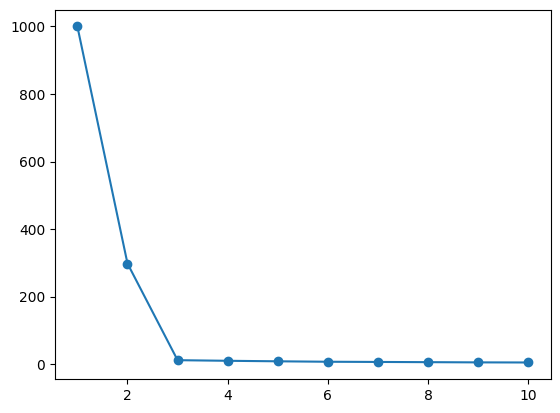

In [68]:
plt.plot(K_range,inertia,marker='o')

In [69]:
kmeans_final = KMeans(n_clusters=3,random_state=42)
cluster_labels = kmeans_final.fit(X_scaled)
cluster_labels

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

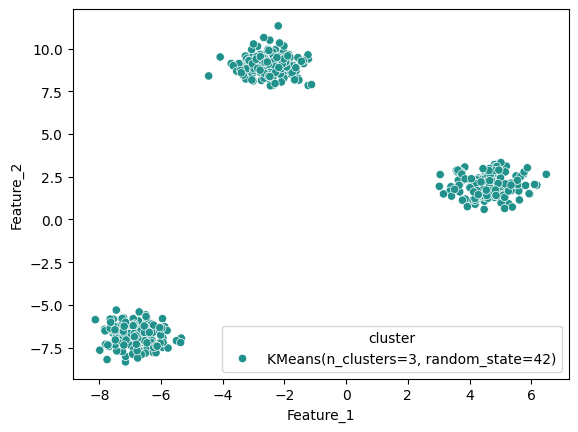

In [72]:
df['cluster'] = cluster_labels
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'],hue=df['cluster'],palette='viridis')

### DB-SCAN

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

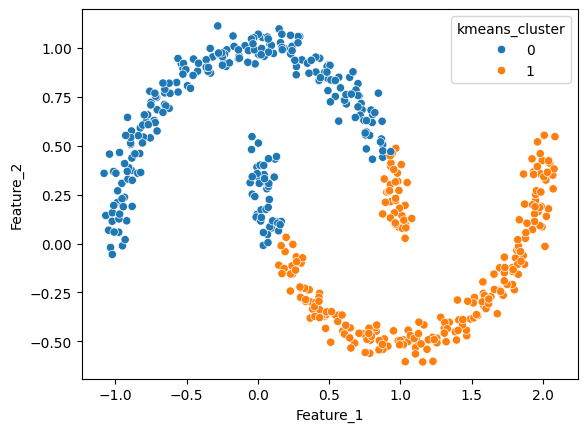

In [76]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
X, y_true = make_moons(n_samples=500, noise=0.05,random_state=42)
df = pd.DataFrame(X,columns=['Feature_1','Feature_2'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
kmeans = KMeans(n_clusters=2,random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['kmeans_cluster'] = kmeans_labels
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'],hue=df['kmeans_cluster'],palette='tab10')

### Dimensionality Reduction (PCA)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

X,y = make_blobs(n_samples=500,n_features=5,centers=3,cluster_std=1.5,random_state=42)
X 

array([[ -9.85712583,   9.52196609,   6.40680626,  -6.81757623,
         -7.86054541],
       [ -8.04717781,   8.40261648,   6.40946097,  -4.33576029,
         -6.70289196],
       [ -3.73690895,   6.7601386 ,   4.24877609,   0.28504117,
         -7.10318219],
       ...,
       [ -5.82805   ,  -7.29173339,   7.48633693,   2.71623974,
          7.33823548],
       [ -2.48648271,   9.67739715,   6.21190845,   1.03031506,
         -7.54637531],
       [ -8.63901448, -10.68852991,   8.36601977,   4.94211449,
          3.77070371]], shape=(500, 5))

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.07039133,  0.74546814,  0.0859273 , -1.58466105, -0.90798501],
       [-0.52251206,  0.61451192,  0.08731966, -0.95761934, -0.68801347],
       [ 0.78222538,  0.4223533 , -1.04593191,  0.20984645, -0.76407462],
       ...,
       [ 0.14922774, -1.22161917,  0.65212732,  0.82409945,  1.98001159],
       [ 1.16073493,  0.7636525 , -0.01629411,  0.39814317, -0.84828797],
       [-0.70166364, -1.61902103,  1.11350971,  1.38647649,  1.30212699]],
      shape=(500, 5))

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca 

array([[ 1.40522818e+00, -1.73079914e+00],
       [ 1.03463536e+00, -9.82792414e-01],
       [ 1.10182830e+00,  1.09084050e+00],
       [-1.76465839e+00,  1.09970698e-01],
       [ 8.59673831e-01, -1.63970361e+00],
       [ 1.09738958e+00,  1.11937509e+00],
       [ 1.04453451e+00,  1.88953610e+00],
       [-3.14810185e+00, -1.06909853e-01],
       [-1.34287183e+00,  7.48033000e-01],
       [ 4.59419122e-01,  9.66806100e-01],
       [ 1.64897776e+00,  1.95384681e+00],
       [ 7.73369393e-01,  2.09584610e+00],
       [-1.92869648e+00,  9.48608771e-02],
       [ 1.15480661e+00, -1.42564791e+00],
       [ 7.07330515e-01, -1.01056640e+00],
       [ 1.59661674e+00, -1.64931961e+00],
       [-2.40550592e+00, -7.53357753e-01],
       [-1.97627695e+00, -3.59747020e-02],
       [ 1.26193015e+00,  2.72813008e+00],
       [ 1.58339885e+00, -1.46125327e+00],
       [ 1.61435981e+00,  1.29812279e+00],
       [-1.74438705e+00,  1.58820049e-01],
       [-1.88938008e+00,  3.66662930e-01],
       [ 6.

<Axes: xlabel='PC1', ylabel='PC2'>

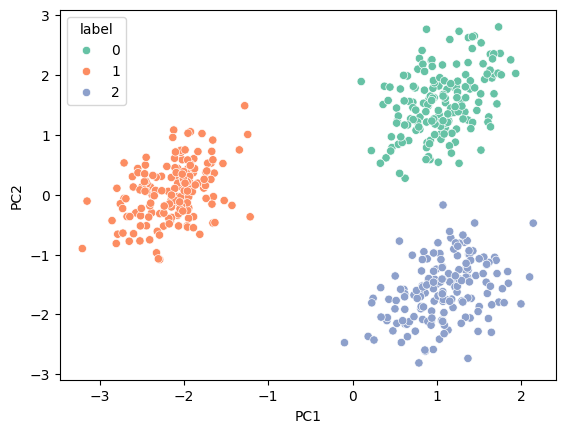

In [5]:
df_pca = pd.DataFrame(X_pca,columns=['PC1','PC2'])
df_pca['label'] = y
sns.scatterplot(data=df_pca,x='PC1',y='PC2',hue='label',palette='Set2')